# BOTalign Angle-Sweep Benchmark on a Noiseless Subtomogram

This notebook evaluates how BOTalign performs as a function of the **ground-truth rotation angle magnitude**.

Setup used here:
- Reference subtomogram: `BOTalign/data/0.1/0.mrc`
- Noiseless synthetic rotations
- No translation handling
- BOTalign parameters fixed to `['wemd', 64, NITER, False]`
- Alignment quality measured against the known inverse rotation

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import mrcfile
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
if not (PROJECT_ROOT / "utils_BO.py").exists():
    raise FileNotFoundError(
        "Run this notebook from BOTalign/notebooks so the parent folder contains utils_BO.py."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from aspire.utils.rotation import Rotation
from aspire.volume import Volume

import wemd
from utils_BO import align_BO, get_angle, u_to_rot

plt.style.use("default")

/home/anshu/subtmgr-align/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Experiment Configuration

The key BOTalign settings are fixed to the choices requested for subtomogram testing:
- WEMD loss
- Downsampling to 64
- Refinement off

Only `NITER`, the tested angle grid, and the number of trials per angle are meant to be tuned.

In [40]:
# REFERENCE_PATH = PROJECT_ROOT / "data" / "emd-3683.mrc"
REFERENCE_PATH = PROJECT_ROOT / "data" / "fixed.mrc"

NITER = 200
ANGLE_GRID_DEG = np.arange(3, 60, 3)
TRIALS_PER_ANGLE = 1
RNG_SEED = 7

PARA = ["wemd", 91, NITER, False]
WAVELET = "sym3"
LEVEL = 6

REFERENCE_PATH, PARA

(PosixPath('/home/anshu/subtmgr-align/BOTalign/data/fixed.mrc'),
 ['wemd', 91, 200, False])

In [4]:
def load_reference_volume(path: Path):
    with mrcfile.open(path) as mrc:
        arr = np.array(mrc.data, dtype=np.float32)
    return Volume(arr), arr


def random_unit_axis(rng: np.random.Generator) -> np.ndarray:
    axis = rng.normal(size=3)
    axis_norm = np.linalg.norm(axis)
    while axis_norm == 0:
        axis = rng.normal(size=3)
        axis_norm = np.linalg.norm(axis)
    return axis / axis_norm


def rotation_from_angle_deg(angle_deg: float, rng: np.random.Generator):
    if angle_deg == 0:
        axis = np.array([1.0, 0.0, 0.0], dtype=np.float32)
        return axis, np.eye(3, dtype=np.float32)

    axis = random_unit_axis(rng).astype(np.float32)
    angle_rad = np.deg2rad(angle_deg)
    R_true = u_to_rot(axis * angle_rad).astype(np.float32)
    return axis, R_true


def wemd_distance(arr_a: np.ndarray, arr_b: np.ndarray, wavelet: str = WAVELET, level: int = LEVEL) -> float:
    emb_a = wemd.embed(arr_a, wavelet, level)
    emb_b = wemd.embed(arr_b, wavelet, level)
    return float(np.linalg.norm(emb_a - emb_b, ord=1))


def run_single_trial(reference_volume: Volume, reference_array: np.ndarray, angle_deg: float, para, rng, trial_idx: int):
    axis, R_true = rotation_from_angle_deg(angle_deg, rng)
    moving_volume = reference_volume.rotate(Rotation(R_true))
    moving_array = moving_volume._data[0]

    tic = time.perf_counter()
    R_init, R_est = align_BO(reference_volume, moving_volume, para)
    toc = time.perf_counter()

    return {
        "trial_idx": trial_idx,
        "true_angle_deg": float(angle_deg),
        "axis_x": float(axis[0]),
        "axis_y": float(axis[1]),
        "axis_z": float(axis[2]),
        "input_wemd": wemd_distance(reference_array, moving_array),
        "init_error_deg": float(get_angle(R_init, R_true.T)),
        "final_error_deg": float(get_angle(R_est, R_true.T)),
        "runtime_s": float(toc - tic),
    }


def summarize_results(results: pd.DataFrame) -> pd.DataFrame:
    return (
        results.groupby("true_angle_deg", as_index=False)
        .agg(
            median_init_error_deg=("init_error_deg", "median"),
            median_final_error_deg=("final_error_deg", "median"),
            mean_final_error_deg=("final_error_deg", "mean"),
            p90_final_error_deg=("final_error_deg", lambda x: np.percentile(x, 90)),
            max_final_error_deg=("final_error_deg", "max"),
            success_le_2deg=("final_error_deg", lambda x: np.mean(x <= 2.0)),
            success_le_5deg=("final_error_deg", lambda x: np.mean(x <= 5.0)),
            mean_runtime_s=("runtime_s", "mean"),
            mean_input_wemd=("input_wemd", "mean"),
        )
        .sort_values("true_angle_deg")
        .reset_index(drop=True)
    )

In [41]:
reference_volume, reference_array = load_reference_volume(REFERENCE_PATH)
print(f"Reference path: {REFERENCE_PATH}")
print(f"Reference shape: {reference_array.shape}")
print(f"Reference dtype: {reference_array.dtype}")
print(f"Reference min/max: {reference_array.min():.4f}, {reference_array.max():.4f}")

Reference path: /home/anshu/subtmgr-align/BOTalign/data/fixed.mrc
Reference shape: (91, 91, 91)
Reference dtype: float32
Reference min/max: -5.4725, 4.8382


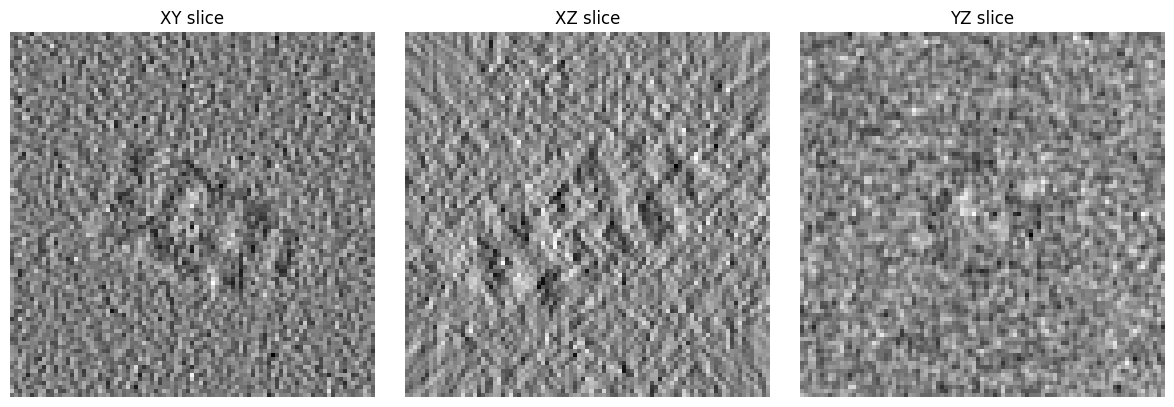

In [42]:
mid = reference_array.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(reference_array[mid], cmap="gray")
axes[0].set_title("XY slice")
axes[1].imshow(reference_array[:, mid, :], cmap="gray")
axes[1].set_title("XZ slice")
axes[2].imshow(reference_array[:, :, mid], cmap="gray")
axes[2].set_title("YZ slice")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

## Run the Angle Sweep

For each target angle magnitude, the notebook samples random axes, rotates the reference subtomogram by the chosen angle, runs BOTalign, and compares the estimated alignment with the known inverse rotation.

In [43]:
rng = np.random.default_rng(RNG_SEED)
records = []

for angle_deg in ANGLE_GRID_DEG:
    print(f"Running angle {angle_deg:>3.0f} deg")
    for trial_idx in range(TRIALS_PER_ANGLE):
        record = run_single_trial(reference_volume, reference_array, angle_deg, PARA, rng, trial_idx)
        records.append(record)

results = pd.DataFrame.from_records(records)
summary = summarize_results(results)

print(f"Finished {len(results)} runs.")
summary

Running angle   3 deg
Running angle   6 deg
Running angle   9 deg
Running angle  12 deg
Running angle  15 deg
Running angle  18 deg
Running angle  21 deg
Running angle  24 deg
Running angle  27 deg
Running angle  30 deg
Running angle  33 deg
Running angle  36 deg
Running angle  39 deg
Running angle  42 deg
Running angle  45 deg
Running angle  48 deg
Running angle  51 deg
Running angle  54 deg
Running angle  57 deg
Finished 19 runs.


,true_angle_deg,median_init_error_deg,median_final_error_deg,mean_final_error_deg,p90_final_error_deg,max_final_error_deg,success_le_2deg,success_le_5deg,mean_runtime_s,mean_input_wemd
0,3.0,2.999961,2.999961,2.999961,2.999961,2.999961,0.0,1.0,40.870525,483460736.0
1,6.0,5.091083,5.091083,5.091083,5.091083,5.091083,0.0,0.0,40.655433,551223808.0
2,9.0,1.248038,1.248038,1.248038,1.248038,1.248038,1.0,1.0,39.627255,588141824.0
3,12.0,3.131504,3.131504,3.131504,3.131504,3.131504,0.0,1.0,40.490106,593937088.0
4,15.0,3.305827,3.305827,3.305827,3.305827,3.305827,0.0,1.0,40.479116,617877888.0
5,18.0,5.533429,5.533429,5.533429,5.533429,5.533429,0.0,0.0,40.739181,650330944.0
6,21.0,14.347349,14.347349,14.347349,14.347349,14.347349,0.0,0.0,41.893956,661270912.0
7,24.0,4.744664,4.744664,4.744664,4.744664,4.744664,0.0,1.0,40.315036,654112576.0
8,27.0,4.500237,4.500237,4.500237,4.500237,4.500237,0.0,1.0,39.845978,687386752.0
9,30.0,3.520365,3.520365,3.520365,3.520365,3.520365,0.0,1.0,40.004375,647615040.0


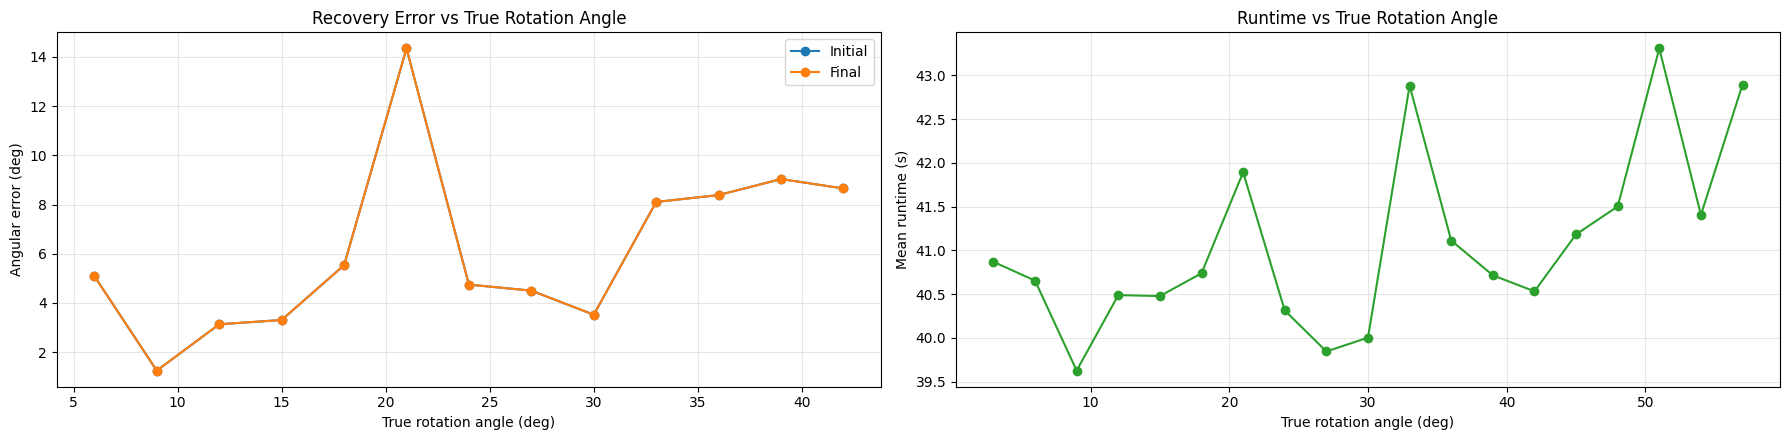

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4.5))

axes[0].plot(summary["true_angle_deg"][1:14], summary["median_init_error_deg"][1:14], marker="o", label="Initial")
axes[0].plot(summary["true_angle_deg"][1:14], summary["median_final_error_deg"][1:14], marker="o", label="Final")
axes[0].set_title("Recovery Error vs True Rotation Angle")
axes[0].set_xlabel("True rotation angle (deg)")
axes[0].set_ylabel("Angular error (deg)")
axes[0].grid(alpha=0.3)
axes[0].legend()


axes[1].plot(summary["true_angle_deg"], summary["mean_runtime_s"], marker="o", color="tab:green")
axes[1].set_title("Runtime vs True Rotation Angle")
axes[1].set_xlabel("True rotation angle (deg)")
axes[1].set_ylabel("Mean runtime (s)")
axes[1].grid(alpha=0.3)

plt.tight_layout()

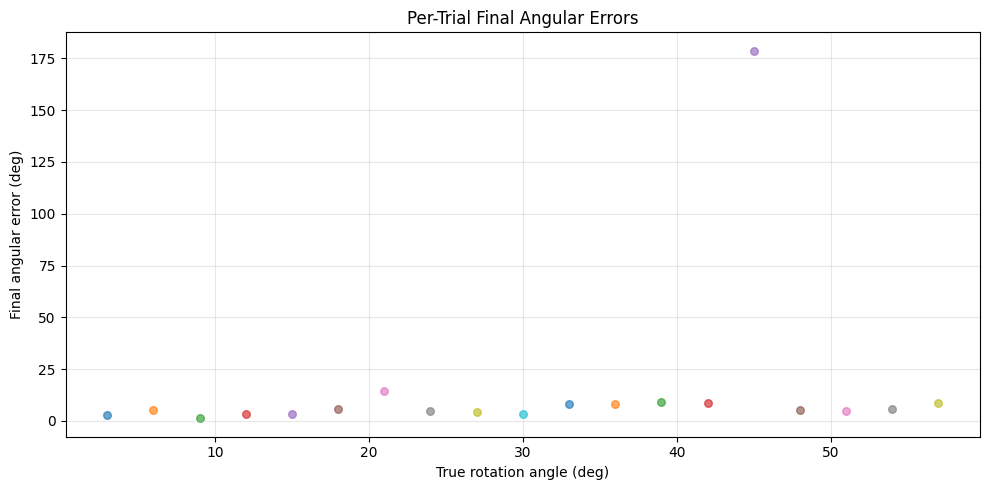

In [47]:
fig, ax = plt.subplots(figsize=(10, 5))
for angle_deg, group in results.groupby("true_angle_deg"):
    x = np.full(len(group), angle_deg)
    ax.scatter(x, group["final_error_deg"], alpha=0.65, s=30)

ax.set_title("Per-Trial Final Angular Errors")
ax.set_xlabel("True rotation angle (deg)")
ax.set_ylabel("Final angular error (deg)")
ax.grid(alpha=0.3)
plt.tight_layout()

In [10]:
summary.to_csv(NOTEBOOK_DIR / "botalign_angle_sweep_summary-em.csv", index=False)
results.to_csv(NOTEBOOK_DIR / "botalign_angle_sweep_all_runs-em.csv", index=False)
print("Saved summary and per-run tables next to the notebook.")

Saved summary and per-run tables next to the notebook.


In [37]:
from aspire.utils.rotation import Rotation

R = Rotation.generate_random_rotations(1)._matrices[0]
angle = get_angle(R, np.eye(3))

theta = np.deg2rad(30)
axis = np.random.randn(3)
axis /= np.linalg.norm(axis)

u = theta * axis
R = u_to_rot(u)
angle = get_angle(R, np.eye(3))
print(R)
print(angle)

[[ 0.89770263 -0.11380658 -0.42565015]
 [ 0.21907257  0.95347726  0.20709506]
 [ 0.38227895 -0.27915806  0.88087094]]
29.99999836607353


## Notes

- `align_BO` is used exactly with the requested configuration: WEMD, downsampling to 64, and refinement off.
- The synthetic moving subtomograms are generated by rotating the same reference subtomogram, so the benchmark is noiseless and translation-free.
- The `input_wemd` column records how far the unaligned moving subtomogram is from the reference in the same WEMD feature space used internally by BOTalign.
- If you later want to test robustness, the natural next steps are adding noise, cropping, or missing-wedge effects while keeping the same notebook structure.